# NOTEBOOK FOR QUICK CALCULATION TESTING
### by Strat
This jupyter notebook is intended to just be for Strat to test around stuff for the eco. Normally doing calculations for balancing and/or seeing how things operate.

It was coded on Python 3.11.9

In [772]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import random
from __future__ import annotations

## Pop spending / banking sim

In [ ]:
# Simulation Variables
pop_spending = np.geomspace(0.25, 262144, 201)
pop_spending = pop_spending.round(3)
np.set_printoptions(suppress=True)
print(pop_spending)

# Food, Iron, Coal, Machinery, CGs, Services, Electricity
sol_spending_weights = [
    [1,   0.5, 0.0, 0.2, 0.0, 0.0, 0.0, 0.0],   # SoL 1–9: Mostly food, a little coal
    [10,  0.4, 0.0, 0.3, 0.0, 0.2, 0.1, 0.0],   # SoL 10–19: Add consumer goods
    [20,  0.3, 0.0, 0.2, 0.0, 0.3, 0.2, 0.0],   # SoL 20–29
    [30,  0.25,0.0, 0.1, 0.0, 0.4, 0.25,0.0],   # SoL 30–39: Heavy consumer goods
    [40,  0.2, 0.0, 0.0, 0.0, 0.35, 0.35, 0.1],   # SoL 40–49: Introduce electricity
    [50,  0.15,0.0, 0.0, 0.0, 0.3, 0.4,0.15], # SoL 50–59: Services and electricity dominate
    [60,  0.1, 0.0, 0.0, 0.0, 0.2, 0.5, 0.2],   # SoL 60+: Primarily services/electricity
]

consumer_confidence = 100.0
banking_confidence = 100.0
reserve_ratio = 0.2

random.seed(42)

[     0.25       0.268      0.287      0.308      0.33       0.354
      0.379      0.406      0.435      0.467      0.5        0.536
      0.574      0.616      0.66       0.707      0.758      0.812
      0.871      0.933      1.         1.072      1.149      1.231
      1.32       1.414      1.516      1.625      1.741      1.866
      2.         2.144      2.297      2.462      2.639      2.828
      3.031      3.249      3.482      3.732      4.         4.287
      4.595      4.925      5.278      5.657      6.063      6.498
      6.964      7.464      8.         8.574      9.19       9.849
     10.556     11.314     12.126     12.996     13.929     14.929
     16.        17.148     18.379     19.698     21.112     22.627
     24.251     25.992     27.858     29.857     32.        34.297
     36.758     39.397     42.224     45.255     48.503     51.984
     55.715     59.714     64.        68.594     73.517     78.793
     84.449     90.51      97.006    103.968    111.43     119

In [ ]:
def safe_div(a, b, default=0.0):
    return a / b if b != 0 else default

def creditworthiness(income, debt, debt_spending, savings=0):
	return 100 + 25 * savings/income - 25 * debt/income - 500 * debt_spending/income

def moving_average(data, window_size):
    averages = []
    for i in range(len(data) - window_size + 1):
        window = data[i:i+window_size]
        averages.append(sum(window) / window_size)
    return averages

def clamp(value, min_val, max_val):
     return max(min_val, min(value, max_val))

def get_spending_weights(sol, weight_table):
    # Assumes the table is sorted by SoL threshold
    active_row = weight_table[0]
    for row in weight_table:
        if sol >= row[0]:
            active_row = row
        else:
            break
    return active_row[1:]  # Skip the SoL threshold

class SimConfig:
    BASE_INTEREST = 0.005
    
class BankStatus:
    FAILED = 0
    CRITICAL = 1
    RESTRICTED = 2
    STRESSED = 3
    HEALTHY = 4

In [ ]:

class Industry:
	def __init__(self, name, inputs=[[None, 0]], outputs=[[None, 0]], workforce=0, base_wage=1.0, scale=1.0):
		self.name = name
		self.workforce = workforce
		self.inputs = inputs
		self.outputs = outputs
		self.base_wage = base_wage
		self.scale = scale
		self.employment_ratio = 1.0
		self.profit = 0.0
	
	def report_supply_demand(self):
		production_scale = self.scale * self.employment_ratio

		for resource, qty in self.inputs:
			resource.demand += qty * production_scale

		for resource, qty in self.outputs:
			resource.supply += qty * production_scale
	
	def run(self):
		# Input cost
		production_scale = self.scale * self.employment_ratio

		input_cost = sum(qty * resource.price for resource,qty in self.inputs) * production_scale
		labor_cost = self.base_wage * self.workforce * production_scale
		revenue = sum(qty * resource.price for resource,qty in self.outputs) * production_scale

		self.profit = revenue - input_cost - labor_cost
	
	def adjust_scale(self):
		if self.profit > 0:
			self.scale *= 1.05
		elif self.profit < 0:
			self.scale *= 0.95
		self.scale = max(self.scale, 0.1)

class Resource:
	def __init__(self, name, base_price):
		self.name = name
		self.supply = 0
		self.demand = 0
		self.base_price = base_price
		self.price = base_price
	
	def reset(self):
		self.supply = 0
		self.demand = 0
	
	def update_price(self):
		if self.supply > 0:
			self.price = self.base_price * self.demand ** 2 / self.supply ** 2
		else:
			self.price = self.base_price * 4

		self.price = clamp(self.price, self.base_price*0.25, self.base_price*4)

class BasicPop:
	def __init__(self, simulation: Simulation, name, size, earnings):
		self.simulation = simulation
		self.name = name
		self.size = size

		self.earnings = earnings
		self.spending = 0.0
		self.spending_goods = 0.0
		self.spending_target = 0.0
		self.spending_debt = 0.0

		self.sol = 10
		self.sol_progress = 0.0

		self.savings = 0.0
		self.savings_target = 0.0
		self.debt = 0.0

		self.consumer_confidence = consumer_confidence

		self.logged_spending = []
		self.logged_savings = []
		self.logged_debt = []
		self.logged_debt_percent = []

		# Initialize sol
		for sol in range(2, 201):
			spending = pop_spending[sol-1] * self.size
			if spending > self.earnings:
				self.sol = sol-1
				break
		
		self.savings_target = self.earnings
		self.savings = self.savings_target

		self.update_pop()
	
	def update_pop(self):
		# Clamp SoL to valid range
		self.sol = clamp(self.sol, 1, 201)

		# Calculate planned spending on goods based on SoL and size
		self.spending_goods = pop_spending[self.sol-1] * self.size

		# Calculate interest and repayment cost of debt
		self.spending_debt = self.debt * self.simulation.bank.interest_rate + self.debt * 0.0033

		# Total planned spending
		self.spending = self.spending_goods + self.spending_debt
		
		# How much of income goes to interest payments
		self.debt_spending_ratio = self.spending_debt / self.earnings
		
		# Threshold for when debt spending starts hurting behavior
		self.debt_spending_limit = (
			0.1 * banking_confidence / 100.0 + 
			0.05 * self.consumer_confidence / 100.0
		)

		# Recalculate consumer confidence based on financial health
		self.consumer_confidence = (
			consumer_confidence 
			- self.debt_spending_ratio * 100 
			+ self.savings / self.earnings * 10
		)

		# Apply harsher confidence penalty if debt spending is excessive
		excess_ratio = self.debt_spending_ratio / self.debt_spending_limit
		if excess_ratio > 1:
			self.consumer_confidence -= (excess_ratio - 1) * 50 + 5

		# Clamp consumer confidence to valid range
		self.consumer_confidence = clamp(self.consumer_confidence, 0, 200)

		# Apply a hit from high interest rates (psychological effect)
		interest_shock = self.simulation.bank.interest_rate - 0.01
		if interest_shock > 0:
			self.consumer_confidence -= interest_shock * 25

		# Target spending based on current income and confidence
		self.spending_target = self.earnings * self.consumer_confidence / 100.0

		# Target savings level based on confidence in banking system
		self.savings_target = self.earnings * banking_confidence / 100.0

		# Update pop's creditworthiness
		self.creditworthiness = creditworthiness(
			self.earnings, 
			self.debt, 
			self.spending_debt, 
			self.savings
		)
	
	def run(self):
		# Finances
		net_money = self.calculate_net_money()
		
		net_money = self.handle_savings(net_money)

		if net_money > 0:
			net_money = self.handle_surplus(net_money)
		else:
			net_money = self.handle_deficit(net_money)

		self.update_standard_of_living(net_money)
		
		self.debt = round(self.debt, 3)
		self.savings = round(self.savings, 3)
		self.update_pop()
		self.log_financials()
		
	def calculate_net_money(self):
		"""Returns the net balance after planned spending."""
		return self.earnings - self.spending

	def handle_surplus(self, net_money):
		"""Uses surplus to repay debt."""
		repayment = net_money * 0.5
		net_money -= self.simulation.bank.repay(self, repayment)
		
		return net_money
	
	def handle_savings(self, net_money):
		"""Deposits or Withdraws from Savings depending on target."""
		if self.savings > self.savings_target:
			withdraw_amount = self.savings - self.savings_target
			self.simulation.bank.withdraw(self, withdraw_amount)
		else:
			deposit_amount = self.savings_target - self.savings
			net_money -= self.simulation.bank.deposit(self, deposit_amount)

		return net_money

	def handle_deficit(self, net_money):
		"""Attempts to borrow to cover shortfall, or cuts back spending."""
		borrow_amount = -net_money

		excess_ratio = self.debt_spending_ratio / self.debt_spending_limit
		if excess_ratio > 4:
			borrow_amount = 0
		elif excess_ratio > 2:
			borrow_amount *= 0.25
		elif excess_ratio > 1:
			borrow_amount *= 0.5

		net_money += self.simulation.bank.borrow(self, borrow_amount)
		return net_money
	
	def update_standard_of_living(self, net_money):
		"""Updates SoL based on net position after financial adjustments."""
		net_target_temp = (self.spending_target - self.spending + net_money) / self.spending_goods * 3

		if net_target_temp > 0.33:
			self.sol_progress += net_target_temp
		elif net_target_temp < -0.33:
			self.sol_progress += net_target_temp / 2

		self.sol_progress = max(self.sol_progress, 0) if self.sol == 1 else self.sol_progress

		while self.sol_progress >= 1:
			self.sol_progress -= 1
			self.sol += 1
		while self.sol_progress <= -1:
			self.sol_progress += 1
			self.sol -= 1

	def log_financials(self):
		"""Logs financial stats for graphing."""
		self.logged_spending.append(self.spending)
		self.logged_savings.append(self.savings)
		self.logged_debt.append(self.debt)
		self.logged_debt_percent.append(self.spending_debt / self.earnings)

	def pop_spending(self, resources):
		spending_level = self.spending_goods  # already defined
		weights = get_spending_weights(self.sol, sol_spending_weights)

		base_prices = [resources[name].base_price for name in resources]

		# How much to buy of each resource (in units)
		quantities = [
			(spending_level * weight / base_price)
			for weight, base_price in zip(weights, base_prices)
		]

		# Apply to resource demand
		for (resource_name, resource), quantity in zip(resources.items(), quantities):
			resource.demand += quantity

class Bank:
	def __init__(self, simulation: Simulation):
		self.interest_rate = 0
		self.lent_out = 0
		self.status = BankStatus.HEALTHY
		self.simulation = simulation

		self.update()
		
	def borrow(self, debtor: BasicPop, amount):
		if amount < 0: return 0
		if self.status == BankStatus.FAILED: return 0

		credit_score = debtor.creditworthiness

		if self.status == BankStatus.CRITICAL:
			if credit_score < self.simulation.creditworthiness_avg:
				return 0
			elif credit_score < self.simulation.creditworthiness_max:
				amount *= 0.25
			else:
				amount *= 0.5
		if self.status == BankStatus.RESTRICTED:
			if credit_score < self.simulation.creditworthiness_avg:
				return 0
			elif credit_score < self.simulation.creditworthiness_max:
				amount *= 0.5
		elif self.status == BankStatus.STRESSED:
			if credit_score < self.simulation.creditworthiness_avg:
				amount *= 0.5

		if amount > self.credit_available:
			# Bank has run out of money
			amount = self.credit_available

		self.lent_out += amount
		debtor.debt += amount

		self.update()

		return amount

	def repay(self, debtor: BasicPop, amount):
		if amount < 0: return 0

		if amount > debtor.debt:
			amount = debtor.debt
		
		self.lent_out -= amount
		debtor.debt -= amount

		self.update()

		return amount
	
	def deposit(self, saver: BasicPop, amount):
		if amount < 0: return 0
		
		if amount > saver.savings_target - saver.savings:
			amount = saver.savings_target - saver.savings

		saver.savings += amount
		self.simulation.total_savings += amount

		self.update()

		return amount
	
	def withdraw(self, saver: BasicPop, amount):
		if amount < 0: return 0
		if self.status == BankStatus.FAILED: return 0

		if amount > saver.savings:
			amount = saver.savings
			
		saver.savings -= amount
		self.simulation.total_savings -= amount

		self.update()

		return amount

	def update(self):

		# Bank Reserves & Credit
		self.reserves = self.simulation.total_savings # + self.central_loan

		self.credit_total = self.reserves / reserve_ratio

		self.credit_available = self.credit_total - self.lent_out
		
		self.reserves_fluid = self.credit_available * reserve_ratio

		self.lent_out_portion = safe_div(self.lent_out, self.credit_total, 1)

		# Interest
		self.interest_rate = SimConfig.BASE_INTEREST + 0.01 * self.lent_out_portion #+ 0.03 * self.lent_out_portion**4
		if self.lent_out_portion > 0.9:
			self.interest_rate += 0.035 * ((self.lent_out_portion - 0.9)*10)**3

		self.interest = self.interest_rate * self.lent_out

		# Bank Status
		self.status = 4

		if self.credit_available < 0:
			self.status = BankStatus.FAILED
		elif self.credit_available < 1 - reserve_ratio / 4:
			self.status = BankStatus.CRITICAL
		elif self.lent_out_portion > 1 - reserve_ratio / 2:
			self.status = BankStatus.STRESSED
		elif self.lent_out_portion > 1 - reserve_ratio:
			self.status = BankStatus.HEALTHY

		return

class Simulation:
	def __init__(
			self, 
			pop_data = [
				["Laborers", 200, 900], 
				["Workers", 50, 500], 
				["Professionals", 5, 90]
			], 
			resources = {
				"Food": Resource("Food", 2.5),
				"Iron": Resource("Iron", 2),
				"Coal": Resource("Coal", 1),
				"Machinery": Resource("Machinery", 25),
				"Consumer Goods": Resource("Consumer Goods", 8),
				"Services": Resource("Services", 5),
				"Electricity": Resource("Electricity", 5)
			}
		):
		self.total_spending = 0
		self.total_savings = 0
		self.total_debt = 0
		self.bank = Bank(self)
		self.resources = resources

		self.pops = [BasicPop(self, name, size, earnings) for name,size,earnings in pop_data] # Array of the pops
		self.total_earnings = sum([x.earnings for x in self.pops])
		self.population = sum([x.size for x in self.pops])
		self.average_consumer_confidence = consumer_confidence

		self.logged_interest_rate = []
		self.logged_consumer_confidence = []
		self.logged_earnings = []
		self.logged_spending = []
		self.logged_bank_status = []

		self.update()

	def update(self):
    	# Aggregate totals across all pops
		self.total_earnings = sum(pop.earnings for pop in self.pops)
		self.population = sum(pop.size for pop in self.pops)
		self.average_consumer_confidence = np.mean([pop.consumer_confidence for pop in self.pops])
		
		self.total_spending = sum(pop.spending for pop in self.pops)
		self.total_savings =  sum(pop.savings for pop in self.pops)
		self.total_debt = sum(pop.debt for pop in self.pops)

    	# Creditworthiness scoring
		self.creditworthiness_scores = [pop.creditworthiness for pop in self.pops]
		max_score = max(self.creditworthiness_scores)
		total_weighted_score = sum(
			score * pop.size for score, pop in zip(self.creditworthiness_scores, self.pops)
		)

		self.creditworthiness_avg = total_weighted_score / self.population if self.population else 0
		self.creditworthiness_max = max_score
				
    	# Recalculate bank state after pop updates
		self.bank.update()

		# Update pop state after any macro-level changes
		for pop in self.pops:
			pop.update_pop()
	
	def run(self):
		for pop in self.pops:
			pop.run()
			self.update_pop_earnings(pop)
		
		self.update()
		self.log_metrics()

	def update_pop_earnings(self, pop: BasicPop):
		"""Adjusts pop earnings based on current economic conditions."""
		multiplier = 0.995 - random.random() * 0.003 + 0.007 * (self.total_spending / self.total_earnings) ** 3
		pop.earnings = round(pop.earnings * multiplier, 3)

	def log_metrics(self):
		"""Logs interest rate, consumer confidence, earnings, spending, and bank status for tracking."""
		self.logged_interest_rate.append(self.interest_rate)
		self.logged_consumer_confidence.append(self.average_consumer_confidence)
		self.logged_earnings.append(self.total_earnings)
		self.logged_spending.append(self.total_spending)
		self.logged_bank_status.append(self.bank_status)

def plot_metric_over_time(pops, metric_name, xtick_interval=30, logged_earnings=[]):
	time_steps = len(getattr(pops[0], metric_name))
	total_series = [0] * time_steps

	plt.figure(figsize=(10, 6))

	for pop in pops:
		series = getattr(pop, metric_name)
		total_series = [t + v for t, v in zip(total_series, series)]
		plt.plot(series, label=pop.name)
		
	# Set x-axis tick labels every `xtick_interval`
	x_ticks = list(range(0, time_steps, xtick_interval))
	plt.xticks(x_ticks)

	if metric_name == "logged_spending":
		plt.plot(logged_earnings, label="Total Earnings", linestyle="--", linewidth=2, color='green')

	plt.plot(total_series, label="Total", linestyle='--', linewidth=2, color='black')
	plt.title(f"{metric_name.replace('_log', '').capitalize()} over time")
	plt.xlabel("Time step")
	plt.ylabel(metric_name.replace('_log', '').capitalize())
	plt.legend()
	plt.grid(True)
	plt.tight_layout()
	plt.show()
	
def plot_metric_over_time_avg(pops, metric_name, xtick_interval=30):
	time_steps = len(getattr(pops[0], metric_name))
	weighted_sum = [0] * time_steps
	total_weights = [0] * time_steps

	plt.figure(figsize=(10, 6))

	for pop in pops:
		series = getattr(pop, metric_name)
		size = pop.size
		weighted_sum = [ws + v * size for ws, v in zip(weighted_sum, series)]
		total_weights = [tw + size for tw in total_weights]
		plt.plot(series, label=pop.name)
	
	weighted_avg = [ws / tw if tw else 0 for ws, tw in zip(weighted_sum, total_weights)]
	plt.plot(weighted_avg, label="Weighted Avg", linestyle='--', linewidth=2, color='black')

	# Set x-axis tick labels every `xtick_interval`
	x_ticks = list(range(0, time_steps, xtick_interval))
	plt.xticks(x_ticks)

	plt.title(f"{metric_name.replace('_log', '').capitalize()} over time")
	plt.xlabel("Time step")
	plt.ylabel(metric_name.replace('_log', '').capitalize())
	plt.legend()
	plt.grid(True)
	plt.tight_layout()
	plt.show()

def plot_sim_metric_over_time(sim, metric_name, xtick_interval=30):
	plt.figure(figsize=(10, 6))
	series = getattr(sim, metric_name)
	time_steps = len(series)
	plt.plot(series, label=metric_name)

	# Set x-axis tick labels every `xtick_interval`
	x_ticks = list(range(0, time_steps, xtick_interval))
	plt.xticks(x_ticks)

	plt.title(f"{metric_name.replace('_log', '').capitalize()} over time")
	plt.xlabel("Time step")
	plt.ylabel(metric_name.replace('_log', '').capitalize())
	plt.legend()
	plt.grid(True)
	plt.tight_layout()
	plt.show()

In [812]:
class SupplySim:
	def __init__(self):
		self.resources = {}
		self.industries = []
		self.logged_gdp = []
		self.sol = 30

	def add_resource(self, name, base_price):
		res = Resource(name, base_price)
		self.resources[name] = res
		return res

	def add_industry(self, name, inputs, outputs, base_wage, workforce, scale=1.0):
		ind = Industry(
			name=name,
			inputs=inputs,
			outputs=outputs,
			base_wage=base_wage,
			workforce=workforce,
			scale=scale
		)
		self.industries.append(ind)
		return ind

	def run_tick(self):
		for res in self.resources.values():
			res.reset()
	
		for ind in self.industries:
			ind.report_supply_demand()
	
		# Inject demand based on total wages
		food = self.resources.get("Food")
		consumer_goods = self.resources.get("Consumer Goods")
		if food and consumer_goods:
			food.demand += self.sol * 2
			consumer_goods.demand += self.sol * 4

			# Estimate income: total wages paid
			total_wages = sum(
				ind.base_wage * ind.workforce * ind.scale * ind.employment_ratio
				for ind in self.industries
			)

			# Estimate consumer cost
			total_cost = (
				food.price * self.sol * 2 +
				consumer_goods.price * self.sol * 4
			)

			# Adjust SoL based on affordability
			if total_cost < total_wages:
				self.sol += 1
			elif total_cost > total_wages:
				self.sol -= 1

			# Clamp SoL to a sane range
			self.sol = clamp(self.sol, 1, 100)
	
		for res in self.resources.values():
			res.update_price()
	
		for ind in self.industries:
			ind.run()
			ind.adjust_scale()

		# GDP via value-added = output revenue - input cost
		gdp = 0.0
		for ind in self.industries:
			scale = ind.scale * ind.employment_ratio

			output_value = sum(qty * res.price for res, qty in ind.outputs) * scale
			input_cost = sum(qty * res.price for res, qty in ind.inputs) * scale

			value_added = output_value - input_cost
			gdp += value_added

		self.logged_gdp.append(gdp)

	def print_state(self):
		print(f"\n--- Aggregate SoL: {self.sol} ---")
		print("\n--- Resources ---")
		for res in self.resources.values():
			print(f"{res.name}: Price={res.price:.2f}, Demand={res.demand:.2f}, Supply={res.supply:.2f}")

		print("\n--- Industries ---")
		for ind in self.industries:
			output_names = ', '.join(f"{res.name}({qty})" for res, qty in ind.outputs)
			print(f"{ind.name}: Scale={ind.scale:.2f}, Profit={ind.profit:.2f}, Outputs=[{output_names}]")

	def plot_gdp_over_time(self):
		import matplotlib.pyplot as plt
		plt.figure(figsize=(10, 5))
		plt.plot(self.logged_gdp, label="GDP", linewidth=2)
		plt.title("Simulated GDP Over Time")
		plt.xlabel("Tick")
		plt.ylabel("GDP (Value Added)")
		plt.grid(True)
		plt.legend()
		plt.tight_layout()
		plt.show()



=== Tick 0 ===

--- Aggregate SoL: 29 ---

--- Resources ---
Food: Price=0.49, Demand=70.00, Supply=100.00
Coal: Price=0.25, Demand=5.00, Supply=100.00
Consumer Goods: Price=8.00, Demand=120.00, Supply=50.00

--- Industries ---
Crop Farm: Scale=0.95, Profit=-1.00, Outputs=[Food(100)]
Coal Mine: Scale=0.95, Profit=-25.00, Outputs=[Coal(100)]
Goods Factory: Scale=1.05, Profit=293.85, Outputs=[Consumer Goods(50)]

=== Tick 1 ===

--- Aggregate SoL: 28 ---

--- Resources ---
Food: Price=0.52, Demand=68.50, Supply=95.00
Coal: Price=0.25, Demand=5.25, Supply=95.00
Consumer Goods: Price=8.00, Demand=116.00, Supply=52.50

--- Industries ---
Crop Farm: Scale=1.00, Profit=1.89, Outputs=[Food(100)]
Coal Mine: Scale=0.90, Profit=-23.75, Outputs=[Coal(100)]
Goods Factory: Scale=1.10, Profit=308.23, Outputs=[Consumer Goods(50)]

=== Tick 2 ===

--- Aggregate SoL: 27 ---

--- Resources ---
Food: Price=0.45, Demand=67.03, Supply=99.75
Coal: Price=0.25, Demand=5.51, Supply=90.25
Consumer Goods: Price=

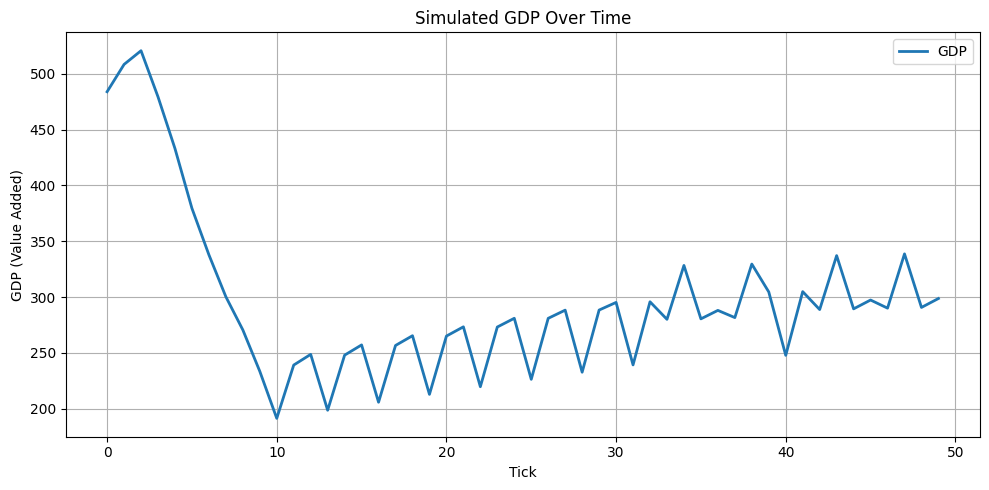

In [816]:
sim = SupplySim()

# Resources
food = sim.add_resource("Food", 1.0)
coal = sim.add_resource("Coal", 1.0)
goods = sim.add_resource("Consumer Goods", 2.0)

# Industries
sim.add_industry("Crop Farm", inputs=[], outputs = [[food, 100]], base_wage=5, workforce=10)
sim.add_industry("Coal Mine", inputs=[], outputs=[[coal, 100]], base_wage=5, workforce=10)
sim.add_industry("Goods Factory", inputs=[[food, 10], [coal, 5]], outputs=[[goods, 50]], base_wage=10, workforce=10)

# Run mini sim
for tick in range(50):
    print(f"\n=== Tick {tick} ===")
    sim.run_tick()
    sim.print_state()

sim.plot_gdp_over_time()

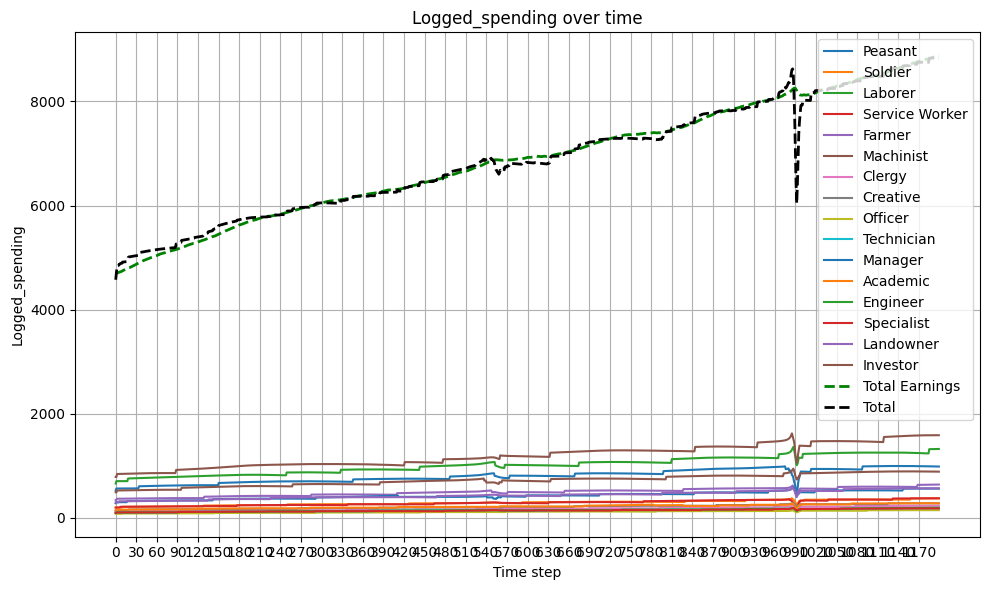

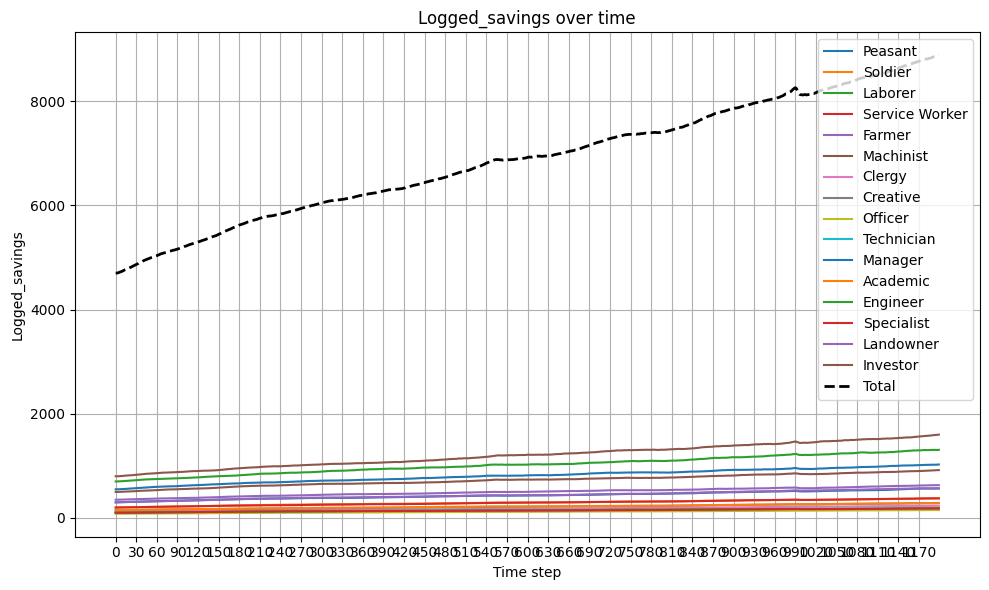

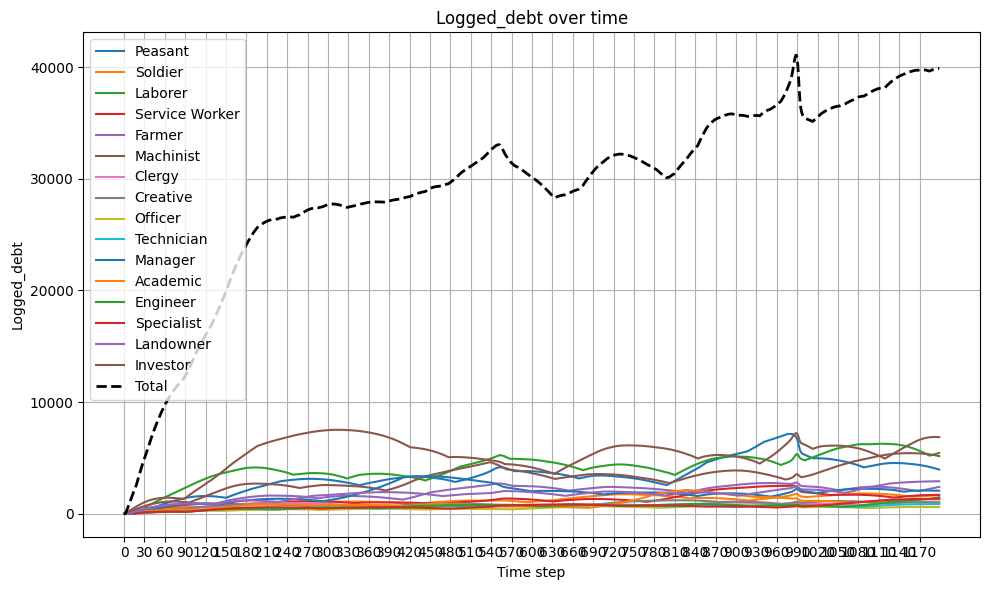

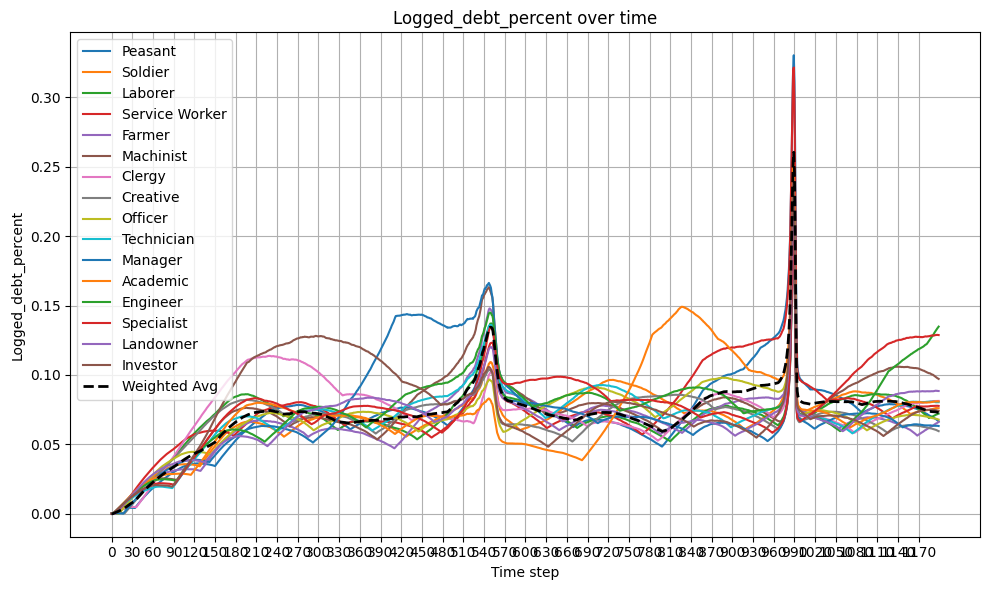

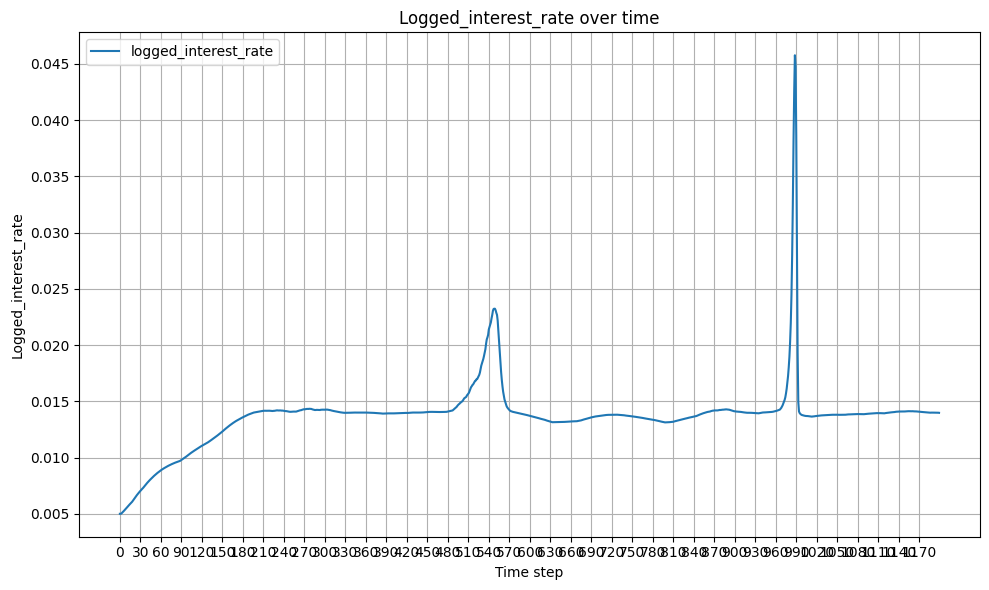

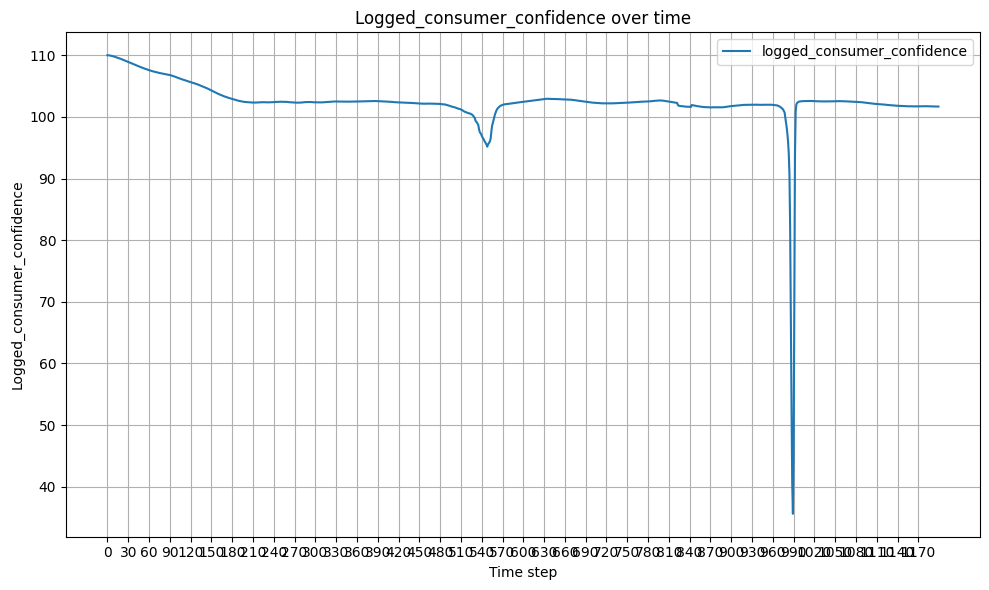

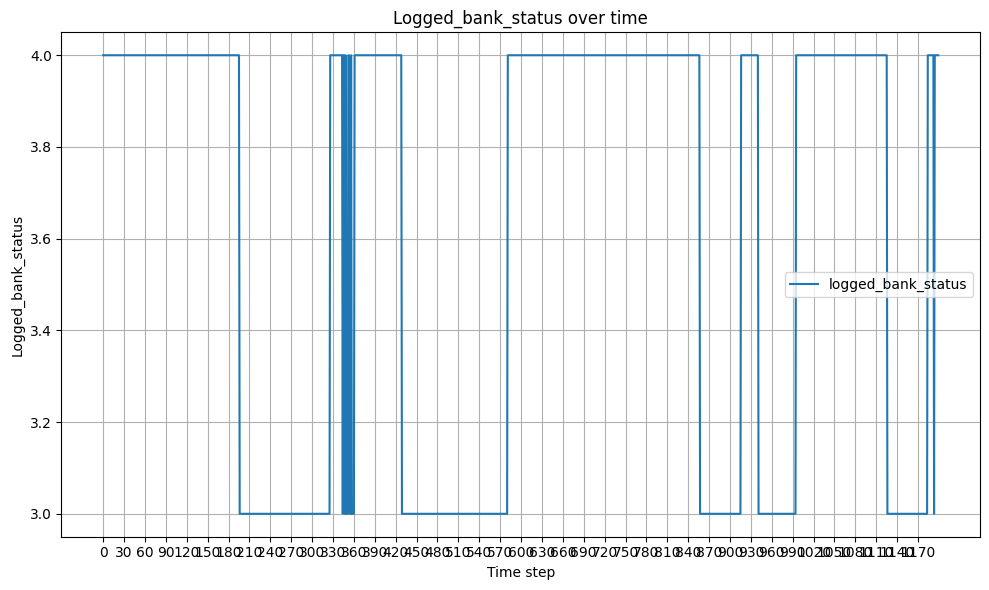

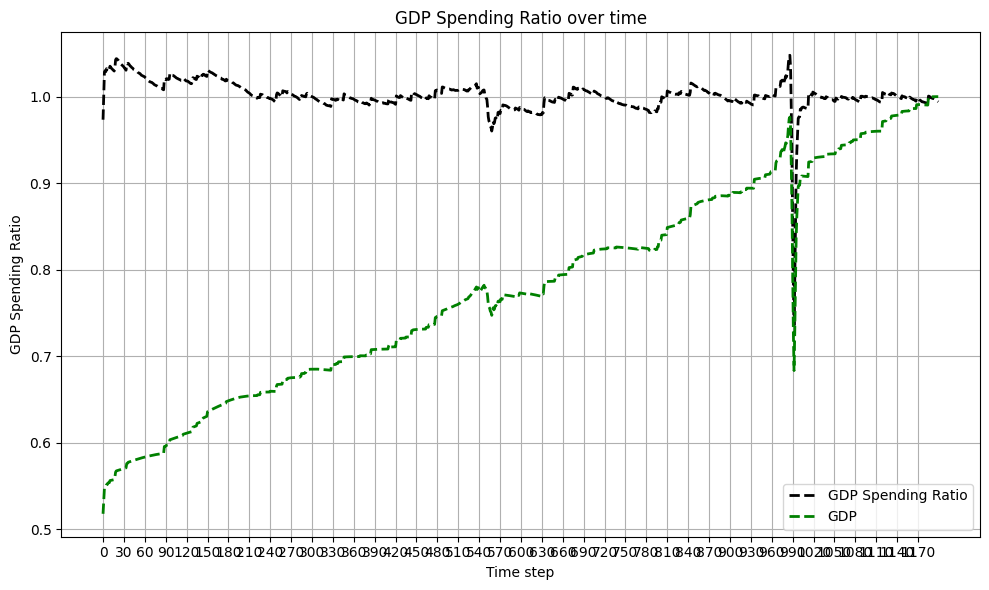

In [ ]:

# Simulation
banking_confidence = 100.0
consumer_confidence = 100.0
reserve_ratio = 0.2

resources = {
	"Food": Resource("Food", 2.5),
	"Iron": Resource("Iron", 2),
	"Coal": Resource("Coal", 1),
	"Machinery": Resource("Machinery", 25),
	"Consumer Goods": Resource("Consumer Goods", 8),
	"Services": Resource("Services", 5),
	"Electricity": Resource("Electricity", 5)
}

food = resources["Food"]
iron = resources["Iron"]
coal = resources["Coal"]
machinery = resources["Machinery"]
consumer_goods = resources["Consumer Goods"]
services = resources["Services"]
electricity = resources["Electricity"]

industries = [
	Industry("Crop Farm", inputs=[[machinery, 1]], outputs=[[food, 25]], jobs=15),
	Industry("Iron Mine", inputs=[[machinery, 1]], outputs=[[iron, 25]], jobs=10),
	Industry("Coal Mine", inputs=[[machinery, 1]], outputs=[[coal, 50]], jobs=10),
	Industry("Mechanical Works", inputs=[[iron, 10], [coal, 10], [electricity, 4]], outputs=[[machinery, 4]], jobs=10),
	Industry("Goods Factory", inputs=[[machinery, 1], [iron, 5], [electricity, 1]], outputs=[[consumer_goods, 10]], jobs=10),
	Industry("Office Park", inputs=[[electricity, 5]], outputs=[[services, 15]], jobs=10),
	Industry("Power Plant", inputs=[[machinery, 1], [coal, 25]], outputs=[[electricity, 20]], jobs=10)
]

sim = Simulation(
	pop_data=[
		["Peasant", 800, 550],
		["Soldier", 200, 200],
		["Laborer", 500, 700],
		["Service Worker", 100, 200],
		["Farmer", 150, 350],
		["Machinist", 200, 500],
		["Clergy", 50, 120],
		["Creative", 50, 150],
		["Officer", 20, 80],
		["Technician", 20, 100],
		["Manager", 50, 300],
		["Academic", 20, 150],
		["Engineer", 10, 100],
		["Specialist", 5, 100],
		["Landowner", 5, 300],
		["Investor", 5, 800]
	]
)

for x in range(1200):
	# Run for 10 years (120 months)
	sim.run()

	# if x % 120 == 119:
	# 	consumer_confidence = 90
	
	# consumer_confidence += random.randint(-5,8) * 0.1
	
# Print/Graph Results
plot_metric_over_time(sim.pops, 'logged_spending', logged_earnings=sim.logged_earnings)
plot_metric_over_time(sim.pops, 'logged_savings')
plot_metric_over_time(sim.pops, 'logged_debt')
plot_metric_over_time_avg(sim.pops, 'logged_debt_percent')
plot_sim_metric_over_time(sim, 'logged_interest_rate')
plot_sim_metric_over_time(sim, 'logged_consumer_confidence')
plot_sim_metric_over_time(sim, 'logged_bank_status')

gdp_spending_ratio = np.array(sim.logged_spending) / np.array(sim.logged_earnings)
plt.figure(figsize=(10, 6))
plt.plot(gdp_spending_ratio, label="GDP Spending Ratio", linestyle='--', linewidth=2, color='black')
plt.plot(np.array(sim.logged_spending)/sim.total_spending, label="GDP", linestyle='--', linewidth=2, color='green')

# Set x-axis tick labels every `xtick_interval`
x_ticks = list(range(0, len(gdp_spending_ratio), 30))
plt.xticks(x_ticks)

plt.title("GDP Spending Ratio over time")
plt.xlabel("Time step")
plt.ylabel("GDP Spending Ratio")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

